# Proyecto #1: Análisis de Sentimientos
## Sebastián Calvo Solano
### Colegio Universitario de Cartago
### Profesor: Osvaldo González Chaves
### Programación II



## Carga de Librerías

Primero se realiza la carga de las liberías con las que se van a estar trabajado durante el proyecto.

In [2]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as sia
import matplotlib.pyplot as plt
from deep_translator import GoogleTranslator as ggt
import seaborn as sns
from wordcloud import WordCloud as wc  

Ahora se carga el dataset a trabajar.

In [3]:
datos = pd.read_csv('comentarios.csv', sep=';', encoding='latin-1')

# Se utiliza "latin-1" debido a que el archivo posee caracteres como tildes (á, é etc) o la letra eñe (ñ) que el tradicional utf-8 no soporta 

print(datos)

comentarios = pd.DataFrame(datos)

print(comentarios)

                                                 texto  sentimiento  categoria
0    Excelente atención y muy buena disposición en ...            1          1
1    Los productos son de alta calidad y siempre ll...            1          1
2    Me encanta el diseño y la funcionalidad de la ...            1          1
3    Estoy muy contento con el producto, superó mis...            1          1
4    El servicio postventa fue excelente, resolvier...            1          1
..                                                 ...          ...        ...
198  El documental que vi sobre la historia del art...            0          2
199  La visita al museo fue frustrante, muchas exhi...            0          2
200  Los talleres extracurriculares han fomentado e...            1          3
201  La integración de tecnología en el aula ha fac...            1          3
202  Los programas de intercambio estudiantil han a...            1          3

[203 rows x 3 columns]
                            

## Prueba de Libería

Una vez se llamaron las librerías y el dataset ya está como un dataframe nos quedaría realizar una prueba para corroborar que funcione correctamente
de sentimientos, por lo cual se realizará una prueba con 6 frases para probrar su uso, 3 en inglés y 3 en español.

In [5]:
frases = ["El código funciona perfecto y sin errores.",
          "Esta aplicación es terrible y muy lenta.",
          "El programa es aceptable, pero falta mejorar.",
          "The code works perfectly without errors.",
          "This application is terrible and very slow.",
          "The program is acceptable, but needs improvement."]

analyzer = sia()
for sentence in frases:
    vs = analyzer.polarity_scores(sentence)
    print("{:-<65} {}".format(sentence, str(vs)))

El código funciona perfecto y sin errores.----------------------- {'neg': 0.33, 'neu': 0.459, 'pos': 0.211, 'compound': -0.3182}
Esta aplicación es terrible y muy lenta.------------------------- {'neg': 0.341, 'neu': 0.659, 'pos': 0.0, 'compound': -0.4767}
El programa es aceptable, pero falta mejorar.-------------------- {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
The code works perfectly without errors.------------------------- {'neg': 0.0, 'neu': 0.391, 'pos': 0.609, 'compound': 0.738}
This application is terrible and very slow.---------------------- {'neg': 0.341, 'neu': 0.659, 'pos': 0.0, 'compound': -0.4767}
The program is acceptable, but needs improvement.---------------- {'neg': 0.0, 'neu': 0.469, 'pos': 0.531, 'compound': 0.6858}


Con la prueba notamos algo y es que la librería no detecta correctamente los sentimientos en español, vemos como la misma frase cambia de puntuación de entre un idioma y el otro por lo cual vamos a probar con el paquete "deep-translator" ya que este nos permite hacer uso del traductor de Google translate y nos permite traducir el texto y ver si los puntajes se asemejan mas unos con otros.

In [6]:
frases = ["El código funciona perfecto y sin errores.",
          "Esta aplicación es terrible y muy lenta.",
          "El programa es aceptable, pero falta mejorar.",
          "The code works perfectly without errors.",
          "This application is terrible and very slow.",
          "The program is acceptable, but needs improvement."]

analyzer = sia()
traductor = ggt(source='auto', target='en')

for sentence in frases:
        traduccion = traductor.translate(sentence)
        vs = analyzer.polarity_scores(traduccion)
        print("{:-<65} {}".format(sentence, str(vs)))


El código funciona perfecto y sin errores.----------------------- {'neg': 0.0, 'neu': 0.445, 'pos': 0.555, 'compound': 0.738}
Esta aplicación es terrible y muy lenta.------------------------- {'neg': 0.341, 'neu': 0.659, 'pos': 0.0, 'compound': -0.4767}
El programa es aceptable, pero falta mejorar.-------------------- {'neg': 0.0, 'neu': 0.469, 'pos': 0.531, 'compound': 0.6858}
The code works perfectly without errors.------------------------- {'neg': 0.0, 'neu': 0.391, 'pos': 0.609, 'compound': 0.738}
This application is terrible and very slow.---------------------- {'neg': 0.341, 'neu': 0.659, 'pos': 0.0, 'compound': -0.4767}
The program is acceptable, but needs improvement.---------------- {'neg': 0.0, 'neu': 0.469, 'pos': 0.531, 'compound': 0.6858}


Vemos que los puntajes cambiaron y ahora si hay similitudes entre ellos (inclusive el último teniendo la misma calificación) por lo cual se va a trabajar con esta función.

## Obtención de Categorías

Ahora que ya se hizo una prueba de la librería para corroborar como se comporta la librería ahora vamos a trabajar con el dataset, siendo lo primero que se va a realizar la obtención de la categoría en la que pertenece el texto.

In [8]:
# Lista vacía para almacenar Tipo_Comentario
Tipo_Opinion = []

for x in comentarios["categoria"]:
     if x == 1:
        Tipo_Opinion.append("opinion")
     elif x == 2:
        Tipo_Opinion.append("cultura")
     elif x == 3:
        Tipo_Opinion.append("educacion")    

comentarios.insert(3, "Tipo_Opinion", Tipo_Opinion)



In [9]:
print(comentarios.head(15))
print(comentarios.tail(15))

                                                texto  sentimiento  categoria  \
0   Excelente atención y muy buena disposición en ...            1          1   
1   Los productos son de alta calidad y siempre ll...            1          1   
2   Me encanta el diseño y la funcionalidad de la ...            1          1   
3   Estoy muy contento con el producto, superó mis...            1          1   
4   El servicio postventa fue excelente, resolvier...            1          1   
5   Muy mala experiencia con la compra, el product...            0          1   
6   El servicio al cliente fue poco profesional y ...            0          1   
7   Me siento decepcionado, la calidad no es como ...            0          1   
8   Tardaron demasiado en responder y no soluciona...            0          1   
9   No recomendaría este servicio, tuve problemas ...            0          1   
10  La exposición de arte fue increíble, muy bien ...            1          2   
11  El evento cultural super

Ya las categorías de las opiniones están, se muestran los primeros y últimos 15 elementos para identificar que efectivamente se insertaron de manera correcta los datos.

## Análisis de Sentimientos

Ahora se procede iniciar con el análisis de sentimientos.

In [10]:
analyzer = sia()
traductor = ggt(source='auto', target='en')

sentimiento = []
vader = []

for sentence in comentarios["texto"]:
        traduccion = traductor.translate(sentence)
        vs = analyzer.polarity_scores(traduccion)
        vader.append(vs['compound'])

        if vs['compound'] >= 0.05:
         sentimiento.append("positivo")
        elif vs['compound'] <= -0.05:
         sentimiento.append("negativo")
        else:
         sentimiento.append("neutral")

comentarios.insert(4, "Tipo_Sentimiento", sentimiento)
comentarios.insert(5, "Calificacion_VADER", vader)     
        



In [72]:
comentarios.head(15)

,texto,sentimiento,categoria,Tipo_Opinion,Tipo_Sentimiento,Calificacion_VADER
0,Excelente atención y muy buena disposición en ...,1,1,opinion,positivo,0.8268
1,Los productos son de alta calidad y siempre ll...,1,1,opinion,positivo,0.4754
2,Me encanta el diseño y la funcionalidad de la ...,1,1,opinion,positivo,0.7964
3,"Estoy muy contento con el producto, superó mis...",1,1,opinion,positivo,0.6115
4,"El servicio postventa fue excelente, resolvier...",1,1,opinion,positivo,0.4767
5,"Muy mala experiencia con la compra, el product...",0,1,opinion,negativo,-0.7841
6,El servicio al cliente fue poco profesional y ...,0,1,opinion,negativo,-0.6688
7,"Me siento decepcionado, la calidad no es como ...",0,1,opinion,negativo,-0.6381
8,Tardaron demasiado en responder y no soluciona...,0,1,opinion,positivo,0.1695
9,"No recomendaría este servicio, tuve problemas ...",0,1,opinion,negativo,-0.5873


## Creación de Gráficos

A continuación procederemos con la creación de gráficos, esto nos mostrará de manera visual datos del análisis de sentimientos, todo los gráficos se van a realizar con la libería "Matplotlib".


## Gráfico de Barras

El primer gráfico con el que vamos a trabajar es con el gráfico de barras, en este proyecto lo utilizaremos para mostrar cual es la distribución de las tres categorías de sentimiento que cuenta el dataset, es decir, "positivo", "negativo" y "neutra".

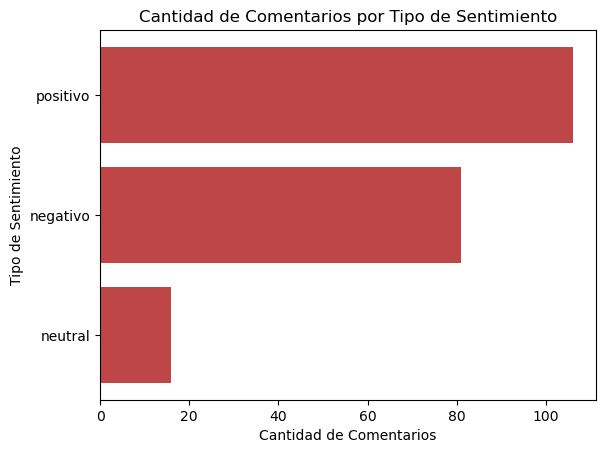

In [37]:
# Conteo de datos
conteo = comentarios["Tipo_Sentimiento"].value_counts().sort_values(ascending=True)

# Gráfico de barras
# "fig, ax" lo que permite es que todo lo que tenga "ax" en su nombre se aplique al gráficos   
fig, ax = plt.subplots()

# Gracias a "ax" el código sabe que tiene que hacer una barra horizontal además del color utilizado
ax.barh(conteo.index, conteo.values, color="#BF4646")

# A continuación se da el título del gráficos y a los ejes "x" y "y"
ax.set_title("Cantidad de Comentarios por Tipo de Sentimiento")
ax.set_xlabel("Cantidad de Comentarios")
ax.set_ylabel("Tipo de Sentimiento")

plt.show()

Con el gráfico de barras notamos que el que posee la mayor cantidad de comentarios es "positivo" con mas de 100 comentarios, le sigue "negativo" con 80 y por último neutral con menos de 20 comentarios.

## Gráfico de Pie

Con el gráfico de barras vimos cantidad ahora veremos porcentajes, en el gráfico de pie veremos cuanto % representa cada uno.

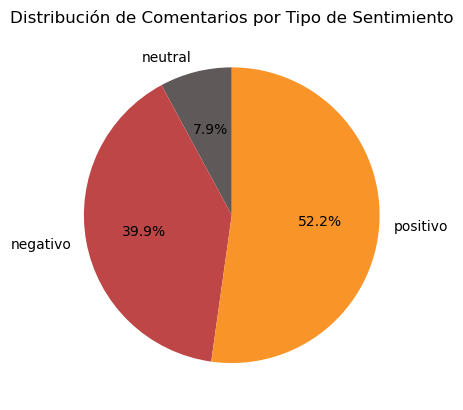

In [46]:
# Gráfico de pie

plt.pie(conteo.values, labels=conteo.index,  autopct='%1.1f%%', startangle=90, colors=["#5F5959", "#BF4646", "#F89428"])
plt.title("Distribución de Comentarios por Tipo de Sentimiento")
plt.show()


Podemos observar que los 100 comentarios que posee "positivo" se refleja por medio de un 52.2%, negativo con un 39.9% y neutral solo un 7.9%.

## Mapa de Calor

Por último haremos un mapa de calor, esto nos ayudará a observar como se correlacionan las variables entre sí



## Nube de Palabras



In [54]:

wordcloud = wordcloud.WordCloud(width=800, height=400, background_color='white').generate(' '.join(comentarios['texto']))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.margins
plt.show()

NameError: name 'wordcloud' is not defined